# FarmPriceNepal – AI Model Training
This notebook trains and evaluates the forecasting models for Nepal's fresh produce markets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import sys

# Add parent dir to path
sys.path.append('..')
from app.services.feature_engineering import create_features

## 1. Load Data
We use the generated synthetic data for training.

## 1.5 Exploratory Data Analysis (EDA)
Here we visualize the crop price distributions, correlations with meteorological parameters, and price shocks during monsoon and festival seasons.

In [ ]:
# Perform EDA & Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('..')
from etl.fetch_events import is_festival, is_monsoon

df['date'] = pd.to_datetime(df['date'])
df['is_monsoon'] = df['date'].apply(lambda x: 1 if is_monsoon(x.date()) else 0)
df['is_festival'] = df['date'].apply(lambda x: 1 if is_festival(x.date()) else 0)

# 1. Price Distribution Plot
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='price_npr', hue='commodity_id', kde=True, bins=50, multiple='stack', palette='viridis')
plt.title('Distribution of Produce Prices in Nepal (NPR)', fontsize=14, fontweight='bold')
plt.xlabel('Price (NPR / kg)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Weather Correlation Heatmap
corr_cols = ['price_npr', 'temp_c', 'humidity_pct', 'rainfall_mm', 'is_monsoon', 'is_festival']
corr_matrix = df[corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, square=True)
plt.title('Weather & Market Price Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Monsoon & Festival Impact Bar Charts
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='commodity_id', y='price_npr', hue='is_monsoon', palette='Blues_r', errorbar=None)
plt.title('Monsoon Shock on Crop Prices', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Crop', fontsize=10)
plt.ylabel('Average Price (NPR)', fontsize=10)

plt.subplot(1, 2, 2)
sns.barplot(data=df, x='commodity_id', y='price_npr', hue='is_festival', palette='Oranges_r', errorbar=None)
plt.title('Festival Shock on Crop Prices', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Crop', fontsize=10)
plt.ylabel('Average Price (NPR)', fontsize=10)

plt.tight_layout()
plt.show()

In [2]:
prices_df = pd.read_csv('../data/prices.csv')
weather_df = pd.read_csv('../data/weather.csv')

# Merge data
df = pd.merge(prices_df, weather_df, left_on=['market_id', 'date'], right_on=['location_id', 'date'])
df.drop(columns=['location_id'], inplace=True)
print(f"Loaded {len(df)} records")
df.head()

Loaded 87720 records


,market_id,commodity_id,date,price_npr,unit,temp_c,humidity_pct,rainfall_mm
0,kalimati,tomato,2024-01-01,62.55,kg,10.6,65.8,0.6
1,kalimati,tomato,2024-01-02,62.91,kg,12.5,56.5,1.1
2,kalimati,tomato,2024-01-03,63.34,kg,11.6,67.9,0.8
3,kalimati,tomato,2024-01-04,62.49,kg,8.4,64.3,1.3
4,kalimati,tomato,2024-01-05,63.18,kg,1.9,53.0,0.4


## 2. Feature Engineering

In [3]:
featured_df = create_features(df)
print(f"Features created. Shape: {featured_df.shape}")
featured_df.columns

Features created. Shape: (84120, 23)


Index(['market_id', 'commodity_id', 'date', 'price_npr', 'unit', 'temp_c',
       'humidity_pct', 'rainfall_mm', 'day_of_week', 'month', 'quarter',
       'is_weekend', 'is_monsoon', 'is_festival', 'price_lag_1', 'price_lag_7',
       'price_lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30',
       'price_change_1d', 'price_change_7d', 'rain_x_monsoon'],
      dtype='str')

## 3. Train-Test Split (Time-based)

In [4]:
# Split based on date to avoid data leakage in time-series
featured_df = featured_df.sort_values('date')
split_idx = int(len(featured_df) * 0.8)

train_df = featured_df.iloc[:split_idx]
test_df = featured_df.iloc[split_idx:]

features = [
    'day_of_week', 'month', 'is_weekend', 'is_monsoon', 'is_festival',
    'price_lag_1', 'price_lag_7', 'price_lag_30',
    'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30',
    'temp_c', 'humidity_pct', 'rainfall_mm', 'rain_x_monsoon'
]
target = 'price_npr'

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

## 4. Train XGBoost Model

In [5]:
model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, early_stopping_rounds=50)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

print("Model training complete")

Model training complete


## 5. Evaluate

In [6]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE: {mae:.2f} NPR")
print(f"RMSE: {rmse:.2f} NPR")
print(f"MAPE: {mape:.2f}%")

MAE: 1.70 NPR
RMSE: 3.70 NPR
MAPE: 1.85%


## 6. Feature Importance

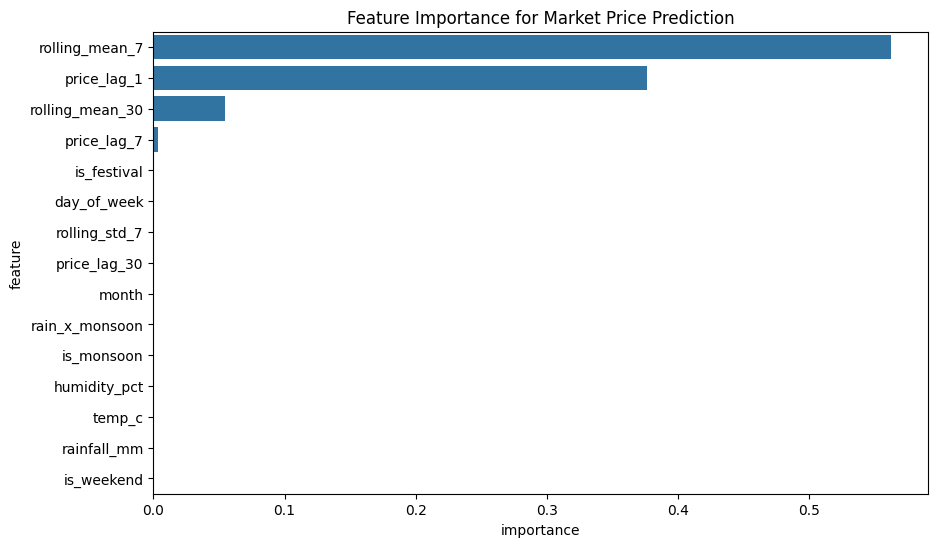

In [7]:
importance = pd.DataFrame({'feature': features, 'importance': model.feature_importances_})
importance = importance.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance)
plt.title('Feature Importance for Market Price Prediction')
plt.show()

## 7. Save Model

In [8]:
os.makedirs('models', exist_ok=True)
joblib.dump(model, 'models/primary_price_model.pkl')
print("Model saved to models/primary_price_model.pkl")

Model saved to models/primary_price_model.pkl
